# Sentiment Analysis using Gemini, Llama3, and OpenAI
## EMC Comments Data Validation Analysis
### 002 - Data Analysis, find compliant projects with the standard domain of codes



### Version History
+ v0.1 - Initial inspection.
  

In [14]:
# -*- coding: utf-8 -*-

### Environment Validation

Using GCP or Azure read in arrays representing minimal library requirements (which might not be present in a Google Colab environment) and install / load the libraries as required.  Additional imports for standard libraries and tailored content to follow.

In [1]:
###########################################
#- Minimal imports to start
###########################################
try:
    import sys
    import subprocess
    import importlib.util
    import atexit
except ImportError as e:
    print("There was a problem importing the most basic libraries necessary for this code.")
    print(repr(e))
    raise SystemExit("Stop right there!")

###########################################
#- Final Exit Routine
###########################################
@atexit.register
def goodbye():
    print("GOODBYE")

###########################################
#- Cloud Environment Setup (Priming)
###########################################
# variables establishing environments
ENV_GCP=0
ENV_AZURE=1
user_input=-1
environments=["GCP", "Azure"]
    
#prompt user for environment before continuing
user_input = 1
while True:
  try:
     if user_input > -1:
         break;
     user_input = int(input("Select the environment you're running: (0) GCP (1) Azure"))     
     if user_input > 1:
         print("Not a valid choice, please try again.")
         continue;
  except ValueError:
     print("Not a valid choice, please try again.")
     continue
  else:
     print(f"Environment selected is: {environments[user_input]}")
     break 
        
############################################
#- Import a custom library, in this case a fairly useful logging framework
############################################
from pathlib import Path
debug_lib_location = Path("../ML-Support")
sys.path.append(str(debug_lib_location))
import debug

libraries=["transformers", "langchain", "backoff",
           "alive-progress", "tqdm", "pyspellchecker", "wordcloud", "langchain", "icecream", "numba", 
           "fitz","dataclasses", "commonregex", "transformers", "spacy", "PyMuPDF", "PyPDF2", "pdfminer", 
           "pdfplumber","pdf2image","pytesseract"]    
debug.msg_info(f"Validating environment for the following pip packages: {libraries}")

#load environment for non-generative libraries
try:
    for library in libraries:
      if library == "Pillow":
        spec = importlib.util.find_spec("PIL")
      else:
        spec = importlib.util.find_spec(library)
      if spec is None:
        print("...installing library " + library)
        subprocess.run(["pip", "install" , library, "--quiet"])
      else:
        print("...library " + library + " already installed.")
except (subprocess.CalledProcessError, Exception) as e:
    print("Error: Failed to install required packages, your code might not run properly.")
    print(repr(e))

#load environment specific libraries for generative AI.
try:    
    if environments[user_input]=="GCP":
      subprocess.run(["pip", "install" , "--upgrade", "google-cloud-aiplatform", "--quiet"])
      gcp_libraries=["google-generativeai", "google-cloud-secret-manager"]
      for library in gcp_libraries:
        spec = importlib.util.find_spec(library)
        if spec is None:
          print("...installing library " + library)
          try:
              subprocess.run(["pip", "install" , library, "--quiet"])
          except (subprocess.CalledProcessError, Exception) as e:
              print("Error: Failed to install required packages, your code might not run properly.")
              print(repr(e))
        else:
          print("...library " + library + " already installed.")
    
        from google.cloud import aiplatform
        import vertexai.preview
        from google.cloud import secretmanager
    elif environments[user_input]=="Azure":
      azure_libraries=["openai", ]
      for library in azure_libraries:
        spec = importlib.util.find_spec(library)
        if spec is None:
          print("...installing library " + library)
          try:
              subprocess.run(["pip", "install" , library, "--quiet"])
          except (subprocess.CalledProcessError, Exception) as e:
              print("Error: Failed to install required packages, your code might not run properly.")
              print(repr(e))
        else:
          print("...library " + library + " already installed.")
    else:
        print("There was a problem processing your request.  Only numeric input of 0 or 1 is allowed.")
        print("Continued operations is not possible without the proper installed tools.")
        raise SystemExit("Stop right there!")
except Exception as e:
    print("There was a problem processing library installs for Generative AI libraries")
    print(repr(e))
    raise SystemExit("Stop right there!")

debug.msg_debug("...dynamic environment installs complete.")

[2024-11-18 22:30:18 UTC]    INFO: Validating environment for the following pip packages: ['transformers', 'langchain', 'backoff', 'alive-progress', 'tqdm', 'pyspellchecker', 'wordcloud', 'langchain', 'icecream', 'numba', 'fitz', 'dataclasses', 'commonregex', 'transformers', 'spacy', 'PyMuPDF', 'PyPDF2', 'pdfminer', 'pdfplumber', 'pdf2image', 'pytesseract'] 
...library transformers already installed.
...library langchain already installed.
...library backoff already installed.
...installing library alive-progress
...library tqdm already installed.
...installing library pyspellchecker
...library wordcloud already installed.
...library langchain already installed.
...library icecream already installed.
...library numba already installed.
...library fitz already installed.
...library dataclasses already installed.
...library commonregex already installed.
...library transformers already installed.
...library spacy already installed.
...installing library PyMuPDF
...library PyPDF2 already 

## Includes and Libraries

In [16]:
debug.msg_info("Library imports")    
############################################
# INCLUDES
############################################

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# a set of libraries that perhaps should always be in Python source
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...core libraries.")
import os
import datetime
import gc
import socket
import sys
import getopt
import inspect
import traceback
import warnings
import json
import pickle
from pathlib import Path
import itertools
import datetime
import re
import shutil
import string
from io import StringIO
import tqdm


import io
import math
import textwrap
import random
import glob
import time
from time import perf_counter
import subprocess
import backoff

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Function Profiling
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
import cProfile
import pstats
import io
from pstats import SortKey

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Data Science Libraries
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...classic data science libraries.")

#optimization routines
from numba import jit
import numpy as np
import scipy as sp
#from sklearn.linear_model import LinearRegression


# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Additional libraries for this work
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...application specific libraries.")
import math
from base64 import b64decode
from IPython.display import Image
import requests
from bs4 import BeautifulSoup                 #used to parse the text
from wordcloud import WordCloud, STOPWORDS    #custom library specifically designed to make word clouds
from spellchecker import SpellChecker
import fitz
#to handle strange characters
from unidecode import unidecode 

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Graphics
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...graphics.")
#import PIL
from PIL import Image
import PIL.ImageOps
import matplotlib as matplt
import matplotlib.pyplot as plt

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# progress bar
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...progress bars.")
from alive_progress import alive_bar
#from alive_progress.styles import showtime, Show
from tqdm.notebook import trange, tqdm
#from tqdm import trange, tqdm

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- PII libraries (regular expressions)
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...regular expressions for PII and transformers for prompt injection defense.")
from commonregex import CommonRegex
from commonregex import email
from commonregex import time
from commonregex import credit_card
from commonregex import ip
from commonregex import ipv6
from commonregex import link
from commonregex import phone
from commonregex import street_address
from commonregex import btc_address

debug.msg_debug("...spacy (pii defense).")
import spacy
from spacy.language import Language
from spacy.tokens import Doc

debug.msg_debug("...hugging face model support.")
#injection defense
from transformers import pipeline

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- Tensorflow AI/ML libraries (seek to use GPU's)
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#load first
try:
    debug.msg_debug("...TensorRT")    
    import tensorrt
    assert tensorrt.Builder(tensorrt.Logger())
except ImportError as ie:
    debug.msg_warning("Failed to import tensorrt, this might be a problem if trying for enhanced processing.")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    #load second
    debug.msg_debug("...TensorFlow")        
    import tensorflow as tf
except ImportError as ie:
    debug.msg_warning("Failed to import tensorflow, might not have a GPU or the proper environment loaded")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    debug.msg_debug("...CUDF")    
    import cudf
except ImportError as ie:
    debug.msg_warning("Failed to import cudf, likely don't have a GPU")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    debug.msg_debug("...Torch")    
    import torch
except ImportError as ie:
    debug.msg_warning("Failed to import torch, likely don't have a GPU or access to that library.")
    debug.msg_warning(f"...{repr(ie)}")
    pass

import pandas as pd
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- NLTK required resources
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...natural language processing.")
import nltk
from nltk.stem import PorterStemmer  # A word stemmer based on the Porter stemming algorithm.  Porter, M. "An algorithm for suffix stripping." Program 14.3 (1980): 130-137.
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.tree import tree
#from nltk.book import *
from nltk import FreqDist
from nltk import sent_tokenize, word_tokenize
from nltk.corpus import stopwords    

nltk.download('punkt')
nltk.download("words")
nltk.download("stopwords")
#nltk.download('averaged_perceptron_tagger')      #looks like you have to download select neural layers for specific functions, head to read the erorr output to learn this.


[2024-10-02 12:59:56 UTC]    INFO: Library imports 
[2024-10-02 12:59:56 UTC]   DEBUG: ...core libraries. 
[2024-10-02 12:59:56 UTC]   DEBUG: ...classic data science libraries. 
[2024-10-02 12:59:56 UTC]   DEBUG: ...application specific libraries. 
[2024-10-02 12:59:56 UTC]   DEBUG: ...graphics. 
[2024-10-02 12:59:56 UTC]   DEBUG: ...progress bars. 
[2024-10-02 12:59:56 UTC]   DEBUG: ...regular expressions for PII and transformers for prompt injection defense. 
[2024-10-02 12:59:56 UTC]   DEBUG: ...spacy (pii defense). 
[2024-10-02 12:59:56 UTC]   DEBUG: ...hugging face model support. 
[2024-10-02 12:59:56 UTC]   DEBUG: ...TensorRT 
[2024-10-02 12:59:57 UTC]   DEBUG: ...TensorFlow 
[2024-10-02 12:59:57 UTC]   DEBUG: ...CUDF 
[2024-10-02 12:59:57 UTC] WARNING: Failed to import cudf, likely don't have a GPU 
[2024-10-02 12:59:57 UTC] WARNING: ...ModuleNotFoundError("No module named 'cudf'") 
[2024-10-02 12:59:57 UTC]   DEBUG: ...Torch 
[2024-10-02 12:59:57 UTC]   DEBUG: ...natural langua

[nltk_data] Downloading package punkt to /home/jupyter/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package words to /home/jupyter/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/jupyter/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Functions

### Numpy / Pandas Configuration Settings

In [17]:
def set_library_configuration() -> None:
    
    ############################################
    #- JUPYTER NOTEBOOK OUTPUT CONTROL / FORMATTING
    ############################################
    #pandas set floating point to 4 places to things don't run loose
    debug.msg_info("Setting Pandas and Numpy library options.")    
    pd.set_option('display.max_colwidth', 10) # None if you want to view the full json blob in the printed dataframe, use this
    pd.options.display.float_format = '{:,.4f}'.format
    np.set_printoptions(precision=4)

## Functions

### Custom Exception Display

In [18]:
## Manages exception output.
#  @param   (Exception)             - Exception to expound upon
#  @returns (None)                  - None
def process_exception(inc_exception) -> None:
    print(f"{BOLD_START}(Exception encountered):{BOLD_END} {type(inc_exception).__name__}")
    print(f"Details: {str(inc_exception)}")
    print("Traceback:")
    traceback.print_exc()

In [19]:
def profile_function(func):
    def wrapper(*args, **kwargs):
        pr = cProfile.Profile()
        pr.enable()
        result = func(*args, **kwargs)
        pr.disable()
        s = io.StringIO()
        sortby = SortKey.CUMULATIVE
        ps = pstats.Stats(pr, stream=s).sort_stats(sortby)
        ps.print_stats()
        print(s.getvalue())
        return result
    return wrapper

### Library Versioning Display

In [20]:
## Outputs library version history of effort.
#
#  @returns (None)                  - None
def lib_diagnostics() -> None:

    import pkg_resources
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}") 
    
    package_name_length=40
    package_version_length=20

    # Get installed packages
    the_packages=["cupy", "jupyter-core", "langchain", "langchain-core", "nltk", "numba", "numpy", "pandas", "pydantic", "pyspellchecker", "spacy", "scipy", "scikit-learn", "seaborn", "usaddress", "xarray",]
    the_packages.sort()
    
    installed_dict = {pkg.key: pkg.version for pkg in pkg_resources.working_set}
    installed=list(installed_dict.keys())
    installed.sort()
    
    #for package_idx, package_name in enumerate(installed):
    for idx, name in enumerate(installed):
         if name in the_packages:
             installed_version = installed_dict[name]
             print(f"{name:<40}#: {str(pkg_resources.parse_version(installed_version)):<20}")
   
    try:
        print(f"{'TensorFlow version':<40}#: {str(tf.__version__):<20}")
        print(f"{'     gpu.count:':<40}#: {str(len(tf.config.experimental.list_physical_devices('GPU')))}")
        print(f"{'     cpu.count:':<40}#: {str(len(tf.config.experimental.list_physical_devices('CPU')))}")
    except Exception as e:
        pass

    try:
        print(f"{'Torch version':<40}#: {str(torch.__version__):<20}")
        print(f"{'     GPUs available?':<40}#: {torch.cuda.is_available()}")
        print(f"{'     count':<40}#: {torch.cuda.device_count()}")
        print(f"{'     current':<40}#: {torch.cuda.current_device()}")
    except Exception as e:
        pass


    try:
      print(f"{'OpenAI Azure Version':<40}#: {str(the_openai_version):<20}")
    except Exception as e:
      pass

    print(f"{BOLD_START}List Devices{BOLD_END} #########################################")
    try:
      from tensorflow.python.client import device_lib
      print(device_lib.list_local_devices())
      print("")
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(åe)))

    print(f"{BOLD_START}Devices Counts{BOLD_END} ########################################")
    try:
      print(f"Num GPUs Available: {str(len(tf.config.experimental.list_physical_devices('GPU')))}" )
      print(f"Num CPUs Available: {str(len(tf.config.experimental.list_physical_devices('CPU')))}" )
      print("")
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(e)))

    print(f"{BOLD_START}Optional Enablement{BOLD_END} ####################################")
    try:
      gpus = tf.config.experimental.list_physical_devices('GPU')
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(e)))

    if gpus:
      # Restrict TensorFlow to only use the first GPU
      try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print( str( str(len(gpus)) + " Physical GPUs," + str(len(logical_gpus)) + " Logical GPU") )
      except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(str(repr(e)))
      print("")
        
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}") 
    return

In [21]:
def process_projects() -> pd.DataFrame:

    #____________ _____   ___ _____ _____ _____   ___________     
    #| ___ \ ___ \  _  | |_  |  ___/  __ \_   _| |_   _|  _  \    
    #| |_/ / |_/ / | | |   | | |__ | /  \/ | |     | | | | | |___ 
    #|  __/|    /| | | |   | |  __|| |     | |     | | | | | / __|
    #| |   | |\ \\ \_/ /\__/ / |___| \__/\ | |    _| |_| |/ /\__ \
    #\_|   \_| \_|\___/\____/\____/ \____/ \_/    \___/|___/ |___/
    #ProjectNamesNumbersIds_20240927.csv
    #Name^ProjectNumber^ProjectId
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")    
    debug.msg_debug("...reading Project Id's and corresponding information for later union with the data")
    project_df = pd.DataFrame()
    file_path= DATA_DIR + os.sep + "ProjectNamesNumbersIds_20240927.csv"
    debug.msg_debug(f"......processing {file_path}")            
    if os.path.isfile(file_path):
        try:
          project_df = pd.read_csv(file_path, skiprows=1, delimiter=f"{DELIM}",names=["ProjectName", "ProjectNumber", "ProjectId"])
        except Exception as e:
          process_exception(e)
          raise SystemExit("Stop right there!")  
    else:
      error_msg=f"File not found.  You attempted to read: {file_path}.  Verify its existence."
      debug.msg_error(error_msg)
      raise SystemExit("Stop right there!")

    print("")
    print(f"{BOLD_START} DataFrame description:{BOLD_END}")
    print(project_df.describe())
    print("")
    print(f"{BOLD_START} DataFrame information:{BOLD_END}")        
    print(project_df.info())
    print("")  
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")    
    
    return project_df

In [22]:
## Main routine that executes all code, does return a data frame of data for further analysis if desired.
#
#  @param (None)

#turn on profiling to see details about function performance
#@profile_function
def processProjectDataRecords(inc_projects: pd.DataFrame):

    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    
    debug.msg_info(f"Data Read from Source {__name__} {inspect.stack()[0][3]}")
    debug.msg_debug("...file path declaration")
    
    year_ranges=["2020",    "2021",   "2022",   "2023",   "2024"]
    year_formats=["cp1252", "cp1252", "cp1252", "cp1252", "cp1252",]
   
    
    #  .o88b.  .d8b.  d8888b.  .d8b.        .o88b.  .d88b.  .88b  d88. .88b  d88. d88888b d8b   db d888888b .d8888. 
    # d8P  Y8 d8' `8b 88  `8D d8' `8b      d8P  Y8 .8P  Y8. 88'YbdP`88 88'YbdP`88 88'     888o  88 `~~88~~' 88'  YP 
    # 8P      88ooo88 88oobY' 88ooo88      8P      88    88 88  88  88 88  88  88 88ooooo 88V8o 88    88    `8bo.   
    # 8b      88~~~88 88`8b   88~~~88      8b      88    88 88  88  88 88  88  88 88~~~~~ 88 V8o88    88      `Y8b. 
    # Y8b  d8 88   88 88 `88. 88   88      Y8b  d8 `8b  d8' 88  88  88 88  88  88 88.     88  V888    88    db   8D 
    #  `Y88P' YP   YP 88   YD YP   YP       `Y88P'  `Y88P'  YP  YP  YP YP  YP  YP Y88888P VP   V8P    YP    `8888Y' 
    ####################################################################################################################
    #- CARA Comments with Categories applied
    ####################################################################################################################
    df = pd.DataFrame()
    
    debug.msg_debug("Iterating through each year defined in year_ranges and reading each data file into a Pandas DataFrame.")
    for year_idx, year_value in enumerate(year_ranges):
        file_path= DATA_DIR + os.sep + f"CARA_{year_value}_category.txt"    
        debug.msg_debug(f"...processing {file_path}")            
        if os.path.isfile(file_path):
        #open the file, read the contents and close the file
            try:
              loaded_df = pd.read_csv(file_path, skiprows=1, delimiter=f"{DELIM}",names=["ProjectId","LetterId", "Category"])
            except Exception as e:
              process_exception(e)
              raise SystemExit("Stop right there!")  
        else:
          error_msg=f"File not found.  You attempted to read: {file_path}.  Verify its existence."
          debug.msg_error(error_msg)
          raise SystemExit("Stop right there!")
        
        #as each dataset is read in inspect the results.
        df = (
              loaded_df
              if df.size == 0
              else pd.concat([df, loaded_df], ignore_index=True)
             )
        debug.msg_debug("......master dataframe updated.")
    
    print("")
    print(f"{BOLD_START}Data payload{BOLD_END}")
    #LetterId^CommentSequence|CodeNumber|CodeCategory
    #4494090^[1|622.0000.00|Silviculture and Reforestation
    
    print(f"{BOLD_START} DataFrame description:{BOLD_END}")
    print(df.describe())
    print("")
    print(f"{BOLD_START} DataFrame information:{BOLD_END}")        
    print(df.info())
    print("")    
    
    
    #verification by "hand": cat ./CARA_*_category.txt | cut -d\^ -f3  | grep "^\[" | wc -l
    total_records=len(df)
    ####################################################################################################################
    #- Unique list of projects (performed befpre everything is cleaned)
    ####################################################################################################################
    master_unique_projects = df['ProjectId'].unique()
    master_unique_projects_set=set(master_unique_projects)
    
    ####################################################################################################################
    #- Remove Duplicates known to exist due to data setup
    #  Looking through specific columns are there duplicates of (in this case Author and Text) key columns that are exactly the same?  This is almost guaranteed to be a data anomaly.  Remove the content.
    ####################################################################################################################
    debug.msg_info("Duplicate Removal from Core Fields")
    the_columns=['LetterId', 'Category']
    debug.msg_debug("...removing duplicates due to design of the data.")
    debug.msg_debug(f"......number of records before initial duplicate purge: {len(df)}")
    try:
        df = df.drop_duplicates(subset=the_columns)
    except Exception as e:
            process_exception(f"Failed to remove duplicates, investigate:{str(e)}")
    debug.msg_debug(f".......number of records after initial duplicate purge: {len(df)}")
    print("")
    
    ####################################################################################################################
    #- Null Values revealed
    #  Demonstrate where Null fields and analyze the results.
    ####################################################################################################################
    debug.msg_info("Columns that have a NULL value.")
    debug.msg_debug("\n")
    print(df.isnull().sum())
    print("")
    
    ####################################################################################################################
    #- Drop Records if anything is null
    ####################################################################################################################
    debug.msg_info("Dropping Records Only if All Records are Missing")
    try:
        debug.msg_debug(f"...number of records before dropna: {len(df)}")
        df.dropna(inplace=True)
        debug.msg_debug(f"....number of records after dropna: {len(df)}")
    except Exception as e:
        process_exception(f"Failed to drop rows that are completely blank, continuing:{str(e)}")
    print("")

    import matplotlib.pyplot as plt
    import numpy as np

    remainder_records=len(df)
    empty_records=total_records - remainder_records

    y = np.array([empty_records, remainder_records])
    mylabels = ["Empty Records", "Populated Records"]

    plt.pie(y, labels = mylabels)
    plt.show()             
    
    
    ####################################################################################################################
    #- Unique list of projects with any category (performed after everything is cleaned)
    ####################################################################################################################
    debug.msg_info("Creating unique Python SET of projects that have data.")        
    populated_unique_projects = df['ProjectId'].unique()
    populated_unique_projects.sort()
    populated_unique_projects_set=set(populated_unique_projects)
    
    populated_projects_df=pd.DataFrame(populated_unique_projects, columns=['ProjectId'])
    populated_projects_df=populated_projects_df.merge(inc_projects, how='inner', on='ProjectId')    

    debug.msg_info("Populated Projects (any category code) saved to file")
    target_filename=f"./2020-2024"+"_EMC_Validation_002_populatedProjects.csv"
    try:
        populated_projects_df = populated_projects_df.sort_values(by='ProjectName')
        with open(target_filename, "w") as my_file:
            print(f"ProjectId^Project_Name", file=my_file)
            for idx, row in tqdm(populated_projects_df.iterrows(), total=populated_projects_df.shape[0]):
                print(f"{row.ProjectId}^{row.ProjectName}", file=my_file)                
    except (IOError, Exception) as e:
        debug.msg_warning("FAILED to open and write to a file for Populated Projects, you might have corruption, investigate.")
        process_exception(e)

    ####################################################################################################################
    #- Un-populated projects with no category relationships
    ####################################################################################################################
    not_populated_unique_projects_set=master_unique_projects_set - populated_unique_projects_set
    not_populated_unique_projects_list=list(not_populated_unique_projects_set)
    not_populated_unique_projects_list.sort()
    not_populated_unique_projects_df=pd.DataFrame(not_populated_unique_projects_list, columns=["ProjectId"])
    not_populated_unique_projects_df=not_populated_unique_projects_df.merge(inc_projects, how="inner", on="ProjectId")
    
    
    debug.msg_info("Un-Populated Projects (any category code) saved to file")
    target_filename=f"./2020-2024"+"_EMC_Validation_002_unPopulatedProjects.csv"
    try:
        not_populated_unique_projects_df=not_populated_unique_projects_df.sort_values(by="ProjectName")
        with open(target_filename, "w") as my_file:
            print(f"ProjectId^Project_Name", file=my_file)
            for idx, row in tqdm(not_populated_unique_projects_df.iterrows(), total=not_populated_unique_projects_df.shape[0]):
                print(f"{row.ProjectId}^{row.ProjectName}", file=my_file)                
    except (IOError, Exception) as e:
        debug.msg_warning("FAILED to open and write to a file for Un-Populated Projects, you might have corruption, investigate.")
        process_exception(e)

    #METRICS on Projects
    master_proj=len(master_unique_projects_set)
    print(f"{BOLD_START}Total Unique Projects:{BOLD_END} {master_proj}")
    print("")
    not_pop_proj=len(not_populated_unique_projects_set)
    not_pop_proj_percent=(not_pop_proj / master_proj ) * 100.0
    print(f"{BOLD_START}Projects without domains:{BOLD_END} {not_pop_proj} ({not_pop_proj_percent})% ")
    print(not_populated_unique_projects_set)
    print("")
    pop_proj=len(populated_unique_projects_set)
    pop_proj_percent=(pop_proj / master_proj ) * 100.0
    print(f"{BOLD_START}Projects with domains:{BOLD_END} {pop_proj} ({pop_proj_percent})%")
    print(populated_unique_projects_set)
    print("")
    print(f"Total projects accounted for: (Empty):{len(not_populated_unique_projects_set)} + (Populated):{len(populated_unique_projects_set)} = (Total):{len(master_unique_projects_set)}")
    
    
    #Plot on Projects
    import matplotlib.pyplot as plt
    import numpy as np

    y = np.array([not_pop_proj_percent, pop_proj_percent])
    mylabels = ["Projects w/No Data", "Projects w/Data"]

    plt.pie(y, labels = mylabels)
    plt.show()     
    
    ####################################################################################################################
    #- Split categories into atomic columns
    ####################################################################################################################
    debug.msg_info("Decoupling Category data into atomic columns.")    
    category_dict={}
    
    #create a hash of hashes making projectId the key for the first hash and letterId the key for the hash inside that one.
    #now we can query any project and get a domain of letters or categories and counts
    try:
        counter=0
        for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
            #if idx > 0:   #skip the header
                category_value=row.Category
                if (len(category_value) > 5):
                    #split on the delimiter for these values
                    the_categories=category_value.split("|")
                    
                    #each record has three parts, so find the chunks of 3's
                    total_records=int(len(the_categories)/3)
                    
                    #print(f"There are {total_records} category values in this record.")
                    #print("###############################################################")
                    #print(the_categories)
                    #print(len(the_categories))
                    #print(type(the_categories))
                    #print("###############################################################")            
                    if total_records > 0:
                        for catIdx in range(0, total_records, 3):
                            #print(f"     Category2Comment value:{the_categories[idx]}")
                            #print(f"           CategoryId value:{the_categories[idx+1]}")
                            #print(f"        Category Name value:{the_categories[idx+2]}")                    
                            category_dict[counter] = {"ProjectId":        row.ProjectId,
                                                      "LetterId" :        row.LetterId, 
                                                      "Category2Comment": the_categories[catIdx],
                                                      "CategoryId":       the_categories[catIdx+1],
                                                      "CategoryName":     the_categories[catIdx+2],
                                                     }
                            counter=counter+1

        print(f"There are {len(category_dict)} records in this data capture.")
        print(f"There were {counter} iterations through the data.")
        #now that we have every letter tied to it's project Id and a new row for every category assigned save that to a new dataframe
        #category_df=pd.DataFrame(category_dict, columns=["LetterId", "ProjectId", "Comment2Category", "CatetgoryId", "CategoryName"])
        category_df=pd.DataFrame(category_dict)        
        category_df = category_df.transpose()
        
        print(f"{BOLD_START}Category DataFrame description:{BOLD_END}")
        print(category_df.describe())
        print("")
        print(f"{BOLD_START}Category DataFrame information:{BOLD_END}")        
        print(category_df.info())
        print("")
        
    except Exception as e:
        process_exception(e)
    
    ####################################################################################################################
    #- Create "distribution", count of, categories per unique project (dictionary)
    ####################################################################################################################
    debug.msg_info("How many categories are assigned per project?")    
    
    #prime the dictionary
    category_count_dict={}
    
    try:
        for idx,value in enumerate(populated_unique_projects_set):
            category_count_dict[int(value)]=0
    except Exception as e:
        print(f"For ProjectId={value}:")
        process_exception(e)    
        
    #iterate through the category dataframe and count up each instance of a category
    #now we can query any project and get a domain of letters or categories and counts
    try:
        for idx, row in tqdm(category_df.iterrows(), total=category_df.shape[0]):
            project_key=row.ProjectId
            category_count_dict[project_key]=int(category_count_dict[project_key])+1
    except Exception as e:
        process_exception(e)  
        
    category_count_df=pd.DataFrame(list(category_count_dict.items()), columns=["ProjectId", "Counts"])        
    category_count_df['ProjectId'] = category_count_df['ProjectId'].astype(int)
    category_count_df['CategoryCount'] = category_count_df['Counts'].astype(int) 
    category_count_df=category_count_df.merge(inc_projects, how='inner', on='ProjectId')    

    print("")
    print("CATEGORY COUNT DF")
    print(category_count_df.info())
    print(category_count_df.describe())
    print("")
    print("")
    
    #Write results to file
    debug.msg_info("Projects with category code counts (total rows) saved to file")
    target_filename=f"./2020-2024"+"_EMC_Validation_002_projectsWithCategoriesCounts.csv"
    try:
        category_count_df=category_count_df.sort_values(by="ProjectName")
        with open(target_filename, "w") as my_file:
            my_file.write("ProjectId^ProjectName^Counts(Total_Rows)\n")                        
            for idx, row in tqdm(category_count_df.iterrows(), total=category_count_df.shape[0]):
                print(f"{row.ProjectId}^{row.ProjectName}^{row.Counts}", file=my_file)                
    except (IOError, Exception) as e:
        debug.msg_warning("FAILED to open and write to a file for Projects to Catetory Counts (Total Rows), you might have corruption, investigate.")
        process_exception(e)

    #METRICS
    total_elements=len(category_count_dict)
    print(f"{BOLD_START} Do you have the same amount of outputs as the populated project numbers gathered from before?{BOLD_END}")
    print(f"....Previous Populated Projects: {pop_proj}   Calculated values now: {total_elements}")
    print("")
    
    print(f"{BOLD_START} Projects and Counts of assigned Categories: {BOLD_END}")
    category_counts=pd.DataFrame(list(category_count_dict.items()), columns=["ProjectId", "Counts"])
    #category_counts=category_counts.transpose()
    
    print(f"{BOLD_START}Category DataFrame description:{BOLD_END}")
    print(category_counts.describe())
    print("")
    print(f"{BOLD_START}Category DataFrame information:{BOLD_END}")        
    print(category_counts.info())
    print("")
    

    #PLOT
    #category_counts.plot(figsize=(10, 6))
    category_counts.plot.bar(x='ProjectId', y='Counts', rot=50, figsize=(20, 10))
    plt.show()
 
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")    
    return populated_unique_projects_set, category_df

In [26]:
def processAuthoritativeCodes(inc_populated_projects: set, inc_projects_df: pd.DataFrame, inc_category_df: pd.DataFrame) -> None:
    
    #  .d8b.  db    db d888888b db   db  .d88b.  d8888b. d888888b d888888b  .d8b.  d888888b d888888b db    db d88888b 
    # d8' `8b 88    88 `~~88~~' 88   88 .8P  Y8. 88  `8D   `88'   `~~88~~' d8' `8b `~~88~~'   `88'   88    88 88'     
    # 88ooo88 88    88    88    88ooo88 88    88 88oobY'    88       88    88ooo88    88       88    Y8    8P 88ooooo 
    # 88~~~88 88    88    88    88~~~88 88    88 88`8b      88       88    88~~~88    88       88    `8b  d8' 88~~~~~ 
    # 88   88 88b  d88    88    88   88 `8b  d8' 88 `88.   .88.      88    88   88    88      .88.    `8bd8'  88.     
    # YP   YP ~Y8888P'    YP    YP   YP  `Y88P'  88   YD Y888888P    YP    YP   YP    YP    Y888888P    YP    Y88888P 
    ####################################################################################################################
    #- Establish the domain of authoritative categories (read in a data file and clean up)
    ####################################################################################################################
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")    
    
    debug.msg_debug("Read authoritative list of categories into dataframe.")
    file_path= DATA_DIR + os.sep + "CARA_Coding_Structure_20240830.csv"    
    debug.msg_debug(f"...processing {file_path}")            
    if os.path.isfile(file_path):
    #open the file, read the contents and close the file
        try:
            authoritative_category_df = pd.read_csv(file_path, skiprows=1, delimiter=",",names=["TemplateName","CodeCategoryName", "CodeName", "CodeNumber"])
        except Exception as e:
            process_exception(e)
            raise SystemExit("Stop right there!")  
    else:
        error_msg=f"File not found.  You attempted to read: {file_path}.  Verify its existence."
        debug.msg_error(error_msg)
        raise SystemExit("Stop right there!")
        
    if (len(authoritative_category_df) > 0):
      debug.msg_debug("......authoritative category dataframe loaded.")
    
    #METRICS
    print("")
    print(f"{BOLD_START}Data payload{BOLD_END}")
    "Template Name, Code Category Name, Code Name, Code Number"
    
    print(f"{BOLD_START} Authoritative Category DataFrame description:{BOLD_END}")
    print(authoritative_category_df.describe())
    print("")
    print(f"{BOLD_START} Authoritative Category DataFrame information:{BOLD_END}")        
    print(authoritative_category_df.info())
    print("")        
    
    #Write results to file
    debug.msg_info("Authoritative Catagory Codes  (all)")
    target_filename=f"./2020-2024"+"_EMC_Validation_002_categoryCodesAll.csv"
    try:
        authoritative_category_df=authoritative_category_df.sort_values(by=['CodeCategoryName', 'CodeName'])        
        with open(target_filename, "w") as my_file:
            print(f"TemplateName^CodeCategoryName^CodeName^CodeNumber", file=my_file)
            for idx, row in tqdm(authoritative_category_df.iterrows(), total=authoritative_category_df.shape[0]):
            #if idx > 0:   #skip the header
                print(f"{row.TemplateName}^{row.CodeCategoryName}^{row.CodeName}^{row.CodeNumber}", file=my_file)
    except (IOError, Exception) as e:
        debug.msg_warning("FAILED to open and write to a file for all category codes, you might have corruption, investigate.")
        process_exception(e)
    
    
    #verification by "hand": cat ./CARA_*_category.txt | cut -d\^ -f3  | grep "^\[" | wc -l
    total_records=len(authoritative_category_df)
    ####################################################################################################################
    #- Unique list of projects (performed befpre everything is cleaned)
    ####################################################################################################################
    auth_master_unique_category = authoritative_category_df['CodeNumber'].unique()
    auth_master_unique_category_set=set(auth_master_unique_category)

    ####################################################################################################################
    #- Duplicate category codes (code number)
    ####################################################################################################################
    # Find duplicate rows    
    duplicate_auth_master_unique_category_df = authoritative_category_df.duplicated(subset=['CodeNumber'], keep=False)

    print("")
    print("Duplicates DF")
    authoritative_category_df[duplicate_auth_master_unique_category_df]
 
    #Write results to file
    debug.msg_info("Authoritative Catagory Codes that are duplicate saved to file")
    target_filename=f"./2020-2024"+"_EMC_Validation_002_categoryCodeDuplicates.csv"
    try:
        authoritative_category_df=authoritative_category_df.sort_values(by=['CodeCategoryName', 'CodeName'])
        with open(target_filename, "w") as my_file:
            print(f"TemplateName^CodeCategoryName^CodeName^CodeNumber", file=my_file)
            for idx, row in tqdm(authoritative_category_df[duplicate_auth_master_unique_category_df].iterrows(), total=authoritative_category_df[duplicate_auth_master_unique_category_df].shape[0]):
            #if idx > 0:   #skip the header
                print(f"{row.TemplateName}^{row.CodeCategoryName}^{row.CodeName}^{row.CodeNumber}", file=my_file)
    except (IOError, Exception) as e:
        debug.msg_warning("FAILED to open and write to a file for duplicate category codes, you might have corruption, investigate.")
        process_exception(e)
    

    ####################################################################################################################
    #- Remove Duplicates known to exist due to data setup
    #  Looking through specific columns are there duplicates of (in this case Author and Text) key columns that are exactly the same?  This is almost guaranteed to be a data anomaly.  Remove the content.
    ####################################################################################################################
    debug.msg_info("Duplicate Removal from Core Fields")
    the_columns=['CodeName', 'CodeNumber']
    debug.msg_debug("...removing duplicates due to design of the data.")
    debug.msg_debug(f"......number of records before initial duplicate purge: {len(authoritative_category_df)}")
    try:
        authoritative_category_df = authoritative_category_df.drop_duplicates(subset=the_columns)
    except Exception as e:
            process_exception(f"Failed to remove duplicates, investigate:{str(e)}")
    debug.msg_debug(f".......number of records after initial duplicate purge: {len(authoritative_category_df)}")
    print("")
    
    ####################################################################################################################
    #- Null Values revealed
    #  Demonstrate where Null fields and analyze the results.
    ####################################################################################################################
    debug.msg_info("Columns that have a NULL value.")
    debug.msg_debug("\n")
    print(authoritative_category_df.isnull().sum())
    print("")
    
    ####################################################################################################################
    #- Drop Records if anything is null
    ####################################################################################################################
    debug.msg_info("Dropping Records Only if All Records are Missing")
    try:
        debug.msg_debug(f"...number of records before dropna: {len(authoritative_category_df)}")
        authoritative_category_df.dropna(inplace=True)
        debug.msg_debug(f"....number of records after dropna: {len(authoritative_category_df)}")
    except Exception as e:
        process_exception(f"Failed to drop rows that are completely blank, continuing:{str(e)}")
    print("")

    import matplotlib.pyplot as plt
    import numpy as np

    remainder_records=len(authoritative_category_df)
    empty_records=total_records - remainder_records

    y = np.array([empty_records, remainder_records])
    mylabels = ["Duplicate Records", "Remaining Records"]

    plt.pie(y, labels = mylabels)
    plt.show()                 
    
    
    
    ####################################################################################################################
    #- For each project store a "set" of categories with that project to build a domain
    ####################################################################################################################
    debug.msg_info("Create a category domain for each project?")    
    
    category_dict={}
    project_category_domain_dict={}
    #prime the dictionary
    for idx,value in enumerate(inc_populated_projects):
        category_dict[value] = []
    
    #iterate through the category dataframe and count up each instance of a category
    #now we can query any project and get a domain of letters or categories and counts
    try:
        for idx, row in tqdm(inc_category_df.iterrows(), total=inc_category_df.shape[0]):
            #if idx > 0:   #skip the header
            project_key=row.ProjectId
            category_code_value=row.CategoryId
            category_dict[project_key].append(category_code_value)
    except Exception as e:
        debug.msg_warning("Issue with assigning an individual category value appended to its specific projectid in the dictionary.")
        process_exception(e)    

    #print("category_dict.keys()")
    #print("#####################################################")
    #print(category_dict.keys())        
    #print("#####################################################")
    #print("")
        
    try:
        for idx,value in enumerate(category_dict.keys()):
            if value in category_dict:
                project_category_domain_dict[value]=set(category_dict[value])
            else:
                debug.msg_warning(f"{value} (key) not found in category_dict.")
    except Exception as e:
        debug.msg_warning("Issue with assigning a set (array of categories).")
        process_exception(e)    
        
    project_names={}
    try:
        for idx, row in tqdm(inc_projects_df.iterrows(), total=inc_projects_df.shape[0]):
            project_names[row.ProjectId]=row.ProjectName
    except Exception as e:
        debug.msg_warning("Issue with assigning a project name to a project id in the dictionary.")
        process_exception(e)    
    
    
    #METRICS
    pop_proj=len(inc_populated_projects)
    total_elements=len(category_dict)
    print(f"{BOLD_START} Do you have the same amount of outputs as the populated project numbers gathered from before?{BOLD_END}")
    print(f"....Previous Populated Projects: {pop_proj}   General Calculated values now: {total_elements}")
    total_elements=len(project_category_domain_dict)    
    print(f"....Previous Populated Projects: {pop_proj}   Aggregated Calculated values now: {total_elements}")    
    print("")
    
    #FILE OUTPUT
    debug.msg_info("Projects and their Category Code domains")
    target_filename=f"./2020-2024"+"_EMC_Validation_002_projectCategoryCodeDomain.csv"
    try:
        with open(target_filename, "w") as my_file:
            print("ProjectId^Domain", file=my_file)
            for idx,key in enumerate(sorted(project_category_domain_dict.keys())):
                if key in project_category_domain_dict and key in project_names:
                    the_domain=list(project_category_domain_dict[key])
                    the_domain.sort()
                    the_domain_string="^".join(the_domain)
                    print(f"{key}^{project_names[key]}^{the_domain_string}", file=my_file)
    except (IOError, Exception) as e:
        debug.msg_warning("FAILED to open and write to a file project category domains, you might have corruption, investigate.")
        process_exception(e)
    
    ####################################################################################################################
    #- For each project subtract the standard domain from the project domain and vice versa and calculate percent compliance
    ####################################################################################################################

    master_domain_number=len(auth_master_unique_category_set)
    print(f"{BOLD_START} Projects and Domains of assigned Categories compared to the standard set: {BOLD_END}")
    for idx,key in enumerate(project_category_domain_dict.keys()):
        project_domain=project_category_domain_dict[key]
        
        under_representation=auth_master_unique_category_set - project_domain
        under_percent =  len(under_representation) / master_domain_number
        
        over_representation=project_domain - auth_master_unique_category_set
        over_percent =   len(over_representation) / master_domain_number
        
        if idx < 1:
            print(f"ProjectId: {key}:")
            print(f"................under master category: {under_percent:.2%}")
            print(f".................over master category: {over_percent:.2%}")        
            print("")
        
        project_category_domain_dict[key]={ "ProjectId" : key,
                                            "domain" : project_domain,
                                            "underR" : under_representation,
                                            "underP" : under_percent,
                                            "overR"  : over_representation,
                                            "overP"  : over_percent,
                                          }
        
    project_category_representation=pd.DataFrame(project_category_domain_dict)        
    project_category_representation = project_category_representation.transpose()
    project_category_representation['overP'] = project_category_representation['overP'].astype(float)
    project_category_representation['underP'] = project_category_representation['underP'].astype(float)    
    
    print(f"..........{len(project_category_representation)}")
    print(f"{BOLD_START} Authoritative Category to Project Compliance DataFrame description:{BOLD_END}")
    print(project_category_representation.describe())
    print("")
    print(f"{BOLD_START} Authoritative Category to Project Compliance DataFrame information:{BOLD_END}")        
    print(project_category_representation.info())
    print("")        
        
    
    ####################################################################################################################
    #- Graphs
    ####################################################################################################################

    pd.set_option('display.max_colwidth', None) # None if you want to view the full json blob in the printed dataframe, use this
    pd.set_option('display.max_rows', 399)
    
    bottom_range=0.80
    print(f"{BOLD_START} Authoritative Category to Project Bottom Range: ( < {bottom_range:.0%}) {BOLD_END}")        
    underP=project_category_representation.query(f"underP < {bottom_range}")
    if (len(underP) > 0):
        underP.plot.bar(x='ProjectId', y='underP', rot=45, figsize=(8.5, 11))
        underPP=underP[ ["ProjectId","underP","overP" ] ]
        print(underPP.sort_values(by=['underP'],  ascending=False))
    print("")
    print("")

    top_range=0.0
    print(f"{BOLD_START} Authoritative Category to Project Top Range ( > {top_range:.0%}) {BOLD_END}")            
    overP=project_category_representation.query(f"overP > {top_range}")
    if (len(overP) > 0):
        overP.plot.bar(x='ProjectId', y='overP', rot=45, figsize=(8.5, 11))
        overPP=underP[ ["ProjectId","underP","overP" ] ]        
        print(overPP.sort_values(by=['overP'],  ascending=False))
    print("")
    print("")
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")    

In [27]:
def process() -> None:
    projects_df=process_projects()
    
    populated_projects_set, category_df=processProjectDataRecords(projects_df)
    
    processAuthoritativeCodes(populated_projects_set, projects_df, category_df)

## Main

[2024-10-02 13:01:51 UTC]    INFO: Setting Pandas and Numpy library options. 
BEGIN PROGRAM
[2024-10-02 13:01:51 UTC]    INFO: Variable declaration. 
[2024-10-02 13:01:51 UTC]   DEBUG: ...Text Wrapper instantiated. 
[2024-10-02 13:01:51 UTC]    INFO: Entering __main__ lib_diagnostics 
jupyter-core                            #: 5.7.2               
langchain                               #: 0.3.1               
langchain-core                          #: 0.3.6               
nltk                                    #: 3.9.1               
numba                                   #: 0.60.0              
numpy                                   #: 1.26.4              
pandas                                  #: 2.2.3               
pydantic                                #: 2.9.2               
pyspellchecker                          #: 0.8.1               
scikit-learn                            #: 1.5.2               
scipy                                   #: 1.13.1              
seaborn   

I0000 00:00:1727874111.626610   11315 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1727874111.629463   11315 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1727874111.631521   11315 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1727874111.633623   11315 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

[2024-10-02 13:01:51 UTC]    INFO: Data Read from Source __main__ processProjectDataRecords 
[2024-10-02 13:01:51 UTC]   DEBUG: ...file path declaration 
[2024-10-02 13:01:51 UTC]   DEBUG: Iterating through each year defined in year_ranges and reading each data file into a Pandas DataFrame. 
[2024-10-02 13:01:51 UTC]   DEBUG: ...processing /home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/source_data/nlp/EMC_PUBLIC_COMMENTS_RAW/CARA_2020_category.txt 
[2024-10-02 13:01:51 UTC]   DEBUG: ......master dataframe updated. 
[2024-10-02 13:01:51 UTC]   DEBUG: ...processing /home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/source_data/nlp/EMC_PUBLIC_COMMENTS_RAW/CARA_2021_category.txt 
[2024-10-02 13:01:52 UTC]   DEBUG: ......master dataframe updated. 
[2024-10-02 13:01:52 UTC]   DEBUG: ...processing /home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/source_data/nlp/EMC_PUBLIC_COMMENTS_RAW/CARA_2022_category.txt 
[2024-10-02 13:01:52 UTC]   DEBUG: ......master dataframe 

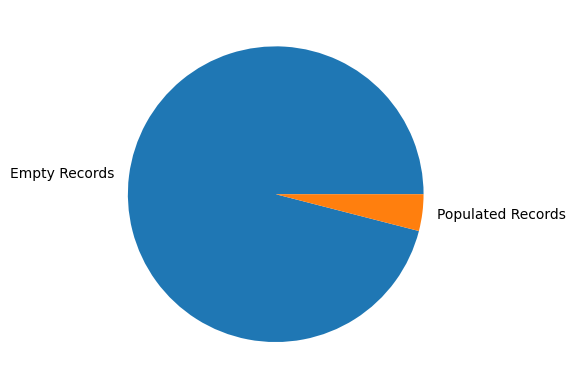

[2024-10-02 13:01:52 UTC]    INFO: Creating unique Python SET of projects that have data. 
[2024-10-02 13:01:52 UTC]    INFO: Populated Projects (any category code) saved to file 


  0%|          | 0/365 [00:00<?, ?it/s]

[2024-10-02 13:01:52 UTC]    INFO: Un-Populated Projects (any category code) saved to file 


  0%|          | 0/894 [00:00<?, ?it/s]

Total Unique Projects: 1314

Projects without domains: 935 (71.15677321156774)% 
{2050, 4101, 6, 4102, 4103, 4105, 4109, 4111, 4113, 4114, 4117, 4122, 4123, 2076, 4124, 4126, 4128, 4129, 4131, 4132, 4134, 4135, 4136, 4137, 4138, 4139, 4141, 4142, 2095, 4143, 4144, 2098, 4146, 4147, 4156, 4157, 4158, 2111, 4159, 4161, 4163, 4165, 2118, 4168, 4170, 4171, 4172, 4175, 2130, 4179, 4180, 4181, 4182, 4186, 4187, 4188, 4189, 4190, 4192, 2146, 2147, 4196, 4197, 4203, 2157, 2168, 4217, 4219, 4220, 2175, 4224, 2178, 4226, 4227, 4228, 4230, 4231, 4233, 4234, 2187, 4235, 4236, 2191, 4241, 4245, 4246, 2199, 4250, 4252, 2206, 4259, 2226, 2239, 2245, 2246, 2249, 2251, 2253, 2260, 2268, 2273, 2280, 2285, 2287, 2291, 2296, 2299, 2308, 2322, 2329, 2332, 2334, 2337, 2338, 294, 2343, 2345, 2349, 2355, 310, 2360, 2369, 2372, 2373, 2380, 2381, 2382, 2383, 2384, 2389, 2390, 2392, 2394, 2395, 2396, 2398, 2401, 2402, 2405, 2408, 2416, 2418, 2420, 2422, 2423, 2425, 2427, 2428, 2429, 2431, 2435, 2436, 2437, 2438,

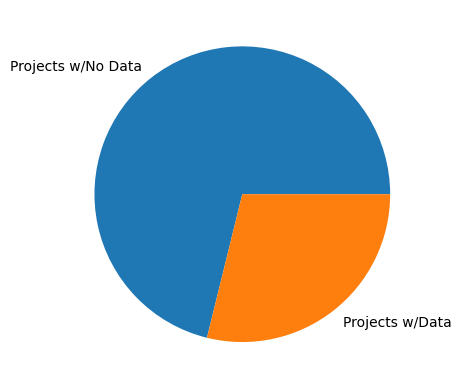

[2024-10-02 13:01:52 UTC]    INFO: Decoupling Category data into atomic columns. 


  0%|          | 0/63324 [00:00<?, ?it/s]

There are 63260 records in this data capture.
There were 63260 iterations through the data.
Category DataFrame description:
        ProjectId  LetterId Category2Comment CategoryId CategoryName
count       63260     63260      63260            63260      63260  
unique        375     63260         26             1653       3684  
top          3524   2442725         [1        801.00...  Not Re...  
freq         5579         1      60346             9294       4092  

Category DataFrame information:
<class 'pandas.core.frame.DataFrame'>
Index: 63260 entries, 0 to 63259
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ProjectId         63260 non-null  object
 1   LetterId          63260 non-null  object
 2   Category2Comment  63260 non-null  object
 3   CategoryId        63260 non-null  object
 4   CategoryName      63260 non-null  object
dtypes: object(5)
memory usage: 2.9+ MB
None

[2024-10-02 13:01:58 UTC]  

  0%|          | 0/63260 [00:00<?, ?it/s]


CATEGORY COUNT DF
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ProjectId      365 non-null    int64 
 1   Counts         365 non-null    int64 
 2   CategoryCount  365 non-null    int64 
 3   ProjectName    365 non-null    object
 4   ProjectNumber  365 non-null    object
dtypes: int64(3), object(2)
memory usage: 14.4+ KB
None
       ProjectId     Counts  CategoryCount
count   365.0000   365.0000   365.0000    
mean  2,957.9973   166.8000   166.8000    
std     725.6214   538.5553   538.5553    
min      23.0000     0.0000     0.0000    
25%   2,568.0000     4.0000     4.0000    
50%   2,978.0000    13.0000    13.0000    
75%   3,438.0000    68.0000    68.0000    
max   4,255.0000 5,579.0000 5,579.0000    


[2024-10-02 13:02:01 UTC]    INFO: Projects with category code counts (total rows) saved to file 


  0%|          | 0/365 [00:00<?, ?it/s]

 Do you have the same amount of outputs as the populated project numbers gathered from before?
....Previous Populated Projects: 379   Calculated values now: 379

 Projects and Counts of assigned Categories: 
Category DataFrame description:
       ProjectId     Counts
count   379.0000   379.0000
mean  2,954.0976   166.9129
std     736.5206   532.4731
min      23.0000     0.0000
25%   2,542.5000     4.0000
50%   2,979.0000    13.0000
75%   3,439.0000    68.0000
max   4,255.0000 5,579.0000

Category DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ProjectId  379 non-null    int64
 1   Counts     379 non-null    int64
dtypes: int64(2)
memory usage: 6.0 KB
None



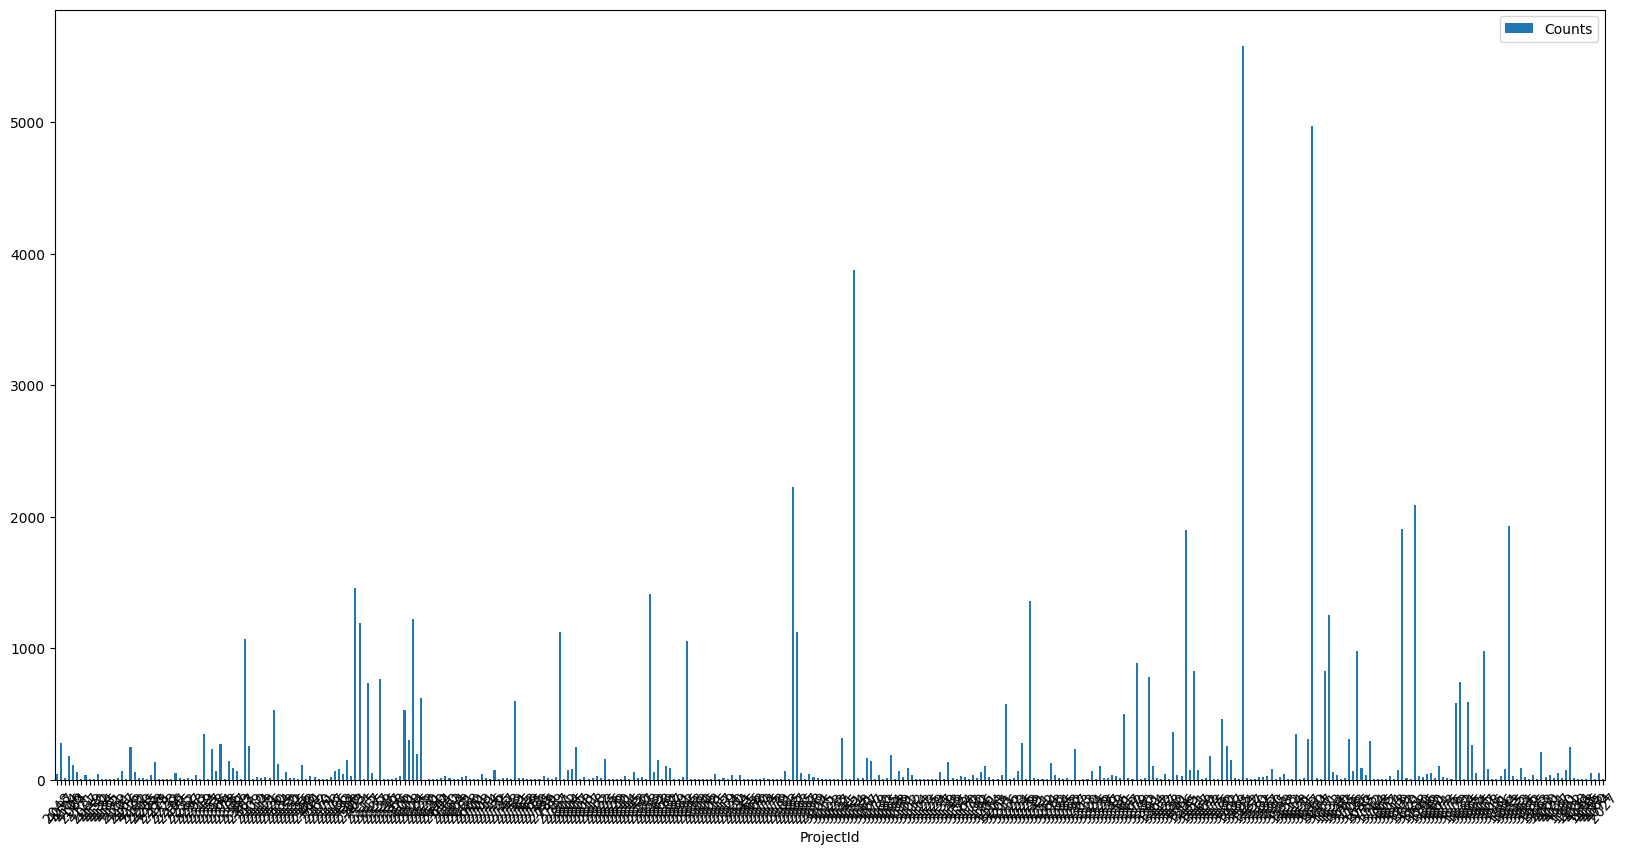

[2024-10-02 13:02:03 UTC]    INFO: Exiting __main__ processProjectDataRecords 
[2024-10-02 13:02:03 UTC]    INFO: Entering __main__ processAuthoritativeCodes 
[2024-10-02 13:02:03 UTC]   DEBUG: Read authoritative list of categories into dataframe. 
[2024-10-02 13:02:03 UTC]   DEBUG: ...processing /home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/source_data/nlp/EMC_PUBLIC_COMMENTS_RAW/CARA_Coding_Structure_20240830.csv 
[2024-10-02 13:02:03 UTC]   DEBUG: ......authoritative category dataframe loaded. 

Data payload
 Authoritative Category DataFrame description:
       TemplateName CodeCategoryName   CodeName CodeNumber
count         468          468              468        468
unique          3            4              307        325
top      Detailed    Issue/...        Climat...  507.01...
freq          285          253                5          3

 Authoritative Category DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data colu

  0%|          | 0/468 [00:00<?, ?it/s]


Duplicates DF
[2024-10-02 13:02:03 UTC]    INFO: Authoritative Catagory Codes that are duplicate saved to file 


  0%|          | 0/283 [00:00<?, ?it/s]

[2024-10-02 13:02:03 UTC]    INFO: Duplicate Removal from Core Fields 
[2024-10-02 13:02:03 UTC]   DEBUG: ...removing duplicates due to design of the data. 
[2024-10-02 13:02:03 UTC]   DEBUG: ......number of records before initial duplicate purge: 468 
[2024-10-02 13:02:03 UTC]   DEBUG: .......number of records after initial duplicate purge: 325 

[2024-10-02 13:02:03 UTC]    INFO: Columns that have a NULL value. 
[2024-10-02 13:02:03 UTC]   DEBUG: 
 
TemplateName        0
CodeCategoryName    0
CodeName            0
CodeNumber          0
dtype: int64

[2024-10-02 13:02:03 UTC]    INFO: Dropping Records Only if All Records are Missing 
[2024-10-02 13:02:03 UTC]   DEBUG: ...number of records before dropna: 325 
[2024-10-02 13:02:03 UTC]   DEBUG: ....number of records after dropna: 325 



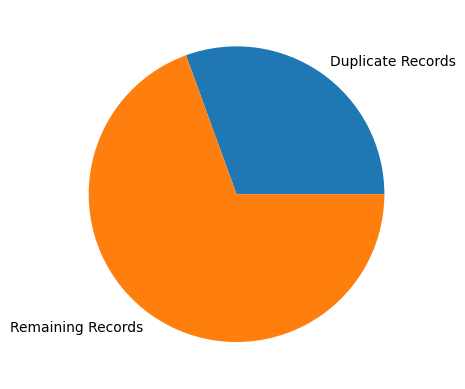

[2024-10-02 13:02:03 UTC]    INFO: Create a category domain for each project? 


  0%|          | 0/63260 [00:00<?, ?it/s]

  0%|          | 0/1372 [00:00<?, ?it/s]

 Do you have the same amount of outputs as the populated project numbers gathered from before?
....Previous Populated Projects: 379   General Calculated values now: 379
....Previous Populated Projects: 379   Aggregated Calculated values now: 379

[2024-10-02 13:02:07 UTC]    INFO: Projects and their Category Code domains 
 Projects and Domains of assigned Categories compared to the standard set: 
ProjectId: 2048:
................under master category: 100.00%
.................over master category: 10.15%

..........379
 Authoritative Category to Project Compliance DataFrame description:
        underP    overP
count 379.0000 379.0000
mean    0.9789   0.0244
std     0.0316   0.0604
min     0.7785   0.0000
25%     0.9754   0.0000
50%     0.9908   0.0031
75%     0.9969   0.0215
max     1.0000   0.5231

 Authoritative Category to Project Compliance DataFrame information:
<class 'pandas.core.frame.DataFrame'>
Index: 379 entries, 2048 to 2027
Data columns (total 6 columns):
 #   Column     N

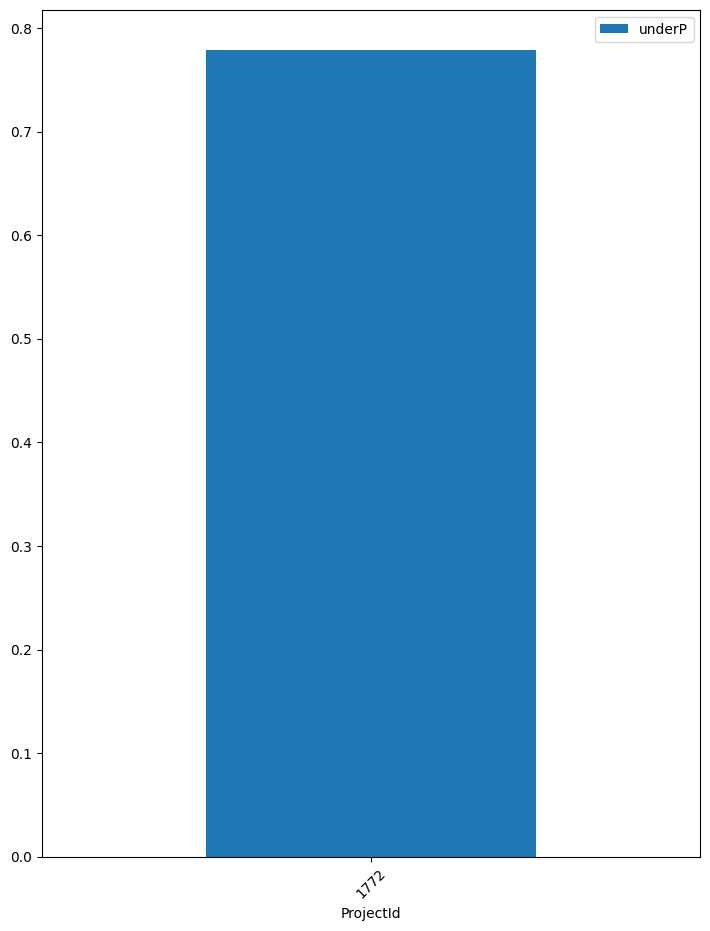

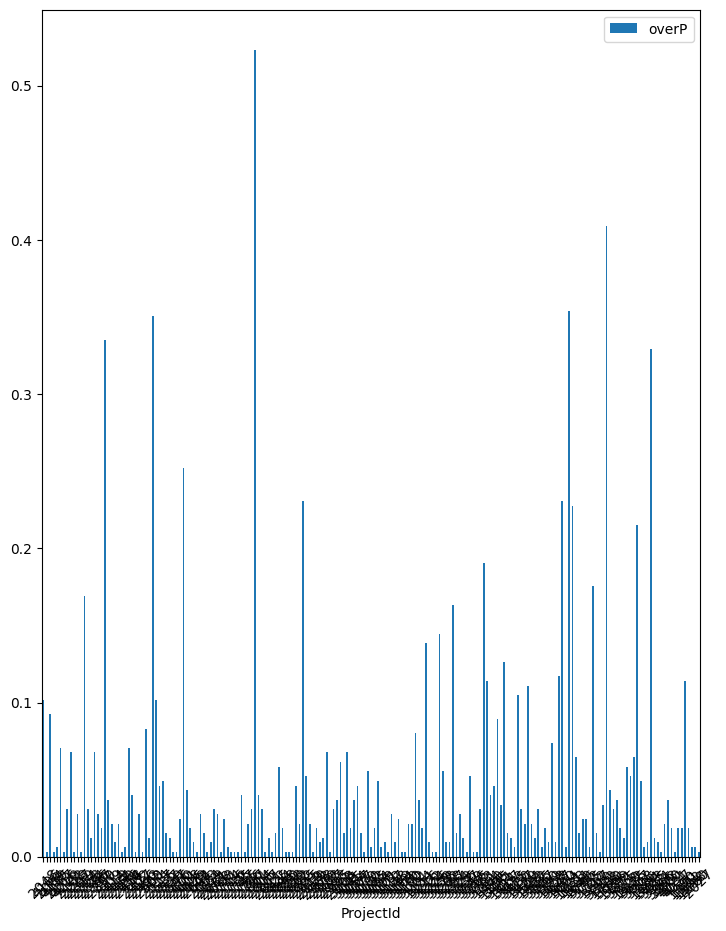

In [28]:
if __name__ == "__main__":

    set_library_configuration()
    start_t=perf_counter()
    print("BEGIN PROGRAM")

    ############################################
    # GLOBAL CONFIGURATION
    ############################################
    #used for values outside standard ASCII, just do it, you'll need it
    ENCODING  ="utf-8"
    os.environ['PYTHONIOENCODING']=ENCODING
    #spacy requirement
    os.environ['TOKENIZERS_PARALLELISM']="false"

    debug.msg_info("Variable declaration.")    
    ############################################
    # GLOBAL VARIABLES
    ############################################
    DEBUG = 1
    DEBUG_DATA = 0
    
    # CODE CONSTRAINTS
    VERSION_NAME    = "CMTANL_DATAANL"
    VERSION_MAJOR   = 0
    VERSION_MINOR   = 1
    VERSION_RELEASE = 0
    DELIM='^'
    TEXT_WIDTH=77
    BOLD_START = "\033[1m"
    BOLD_END = "\033[0;0m"
    
    ###########################################
    #- API Parameters for things like WordCloud
    ###########################################
    IMG_BACKGROUND=None                        #None without quotes or "black", "white", etc...
    IMG_FONT_SIZE_MIN=14
    IMG_WIDTH=800
    IMG_HEIGHT=600
    
    ############################################
    # APPLICATION VARIABLES
    ############################################
    SPELL_CHECK_DISTANCE=2
    MINIMUM_AI_RESPONSE=25                     #words
    MINIMUM_AI_WAIT=15                         #seconds
    os.environ["MINIMUM_AI_WAIT"] = "str(MINIMUM_AI_WAIT)"
    MINIMUM_LETTER_LENGTH=15
    SOURCE_COLUMNS_NAME=["Letter Text"]        #body of text where the actual comment is
    SOURCE_COLUMNS_IDX=[ 10 ]                   #location in data frame AFTER removal of columns
    SOURCE_COLUMN_NAME=SOURCE_COLUMNS_NAME[0]
    EVALUATION_RECORDS=10
    ERROR_PHRASE = 'Error code: 400'
    OPENAI_RESULT="ResultOPENAI"
    
    PROJECT_ID= "usfs-gcp-rand-test-3"
    BUCKET_ID = "usfs-gcp-rand-test3-data-usc1"
    LOCATION = "us-central1"    
    DATA_DIR=f"/home/jupyter/projects/data/{BUCKET_ID}/source_data/nlp/EMC_PUBLIC_COMMENTS_RAW"
        
    ############################################
    # GLOBAL CONFIGURATION
    ############################################
    os.environ['PYTHONIOENCODING']=ENCODING
    os.environ['TOKENIZERS_PARALLELISM']="false"
    
    
    #setup the text wrapper
    debug.msg_debug(f"...Text Wrapper instantiated.")
    wrapper = textwrap.TextWrapper(width=TEXT_WIDTH)
    
    #show your libraries
    lib_diagnostics()
    
    ############################################
    #Core routine
    ############################################
    process()
    
    end_t=perf_counter()
    print("END PROGRAM")
    print(f"Elapsed time: {end_t - start_t}")